# 518880 `1tick -> 2tick -> 1tick` 回正路径研究

这个 notebook 只读取 `data/spread2_close_path/` 下已经生成的 CSV，
不直接加载 snapshot。

核心问题分两层：

- `spread=2` 结束时，是靠原先退开的那一边回来，还是靠另一边继续前进把 spread 合上
- 从扩价前到回正后，`mid` 最终是延续原方向，还是发生回吐


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / 'data').exists():
    if (BASE_DIR.parent / 'data').exists():
        BASE_DIR = BASE_DIR.parent
    elif (BASE_DIR / '518880' / 'data').exists():
        BASE_DIR = BASE_DIR / '518880'
DATA_DIR = BASE_DIR / 'data' / 'spread2_close_path'

def read_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / f'{name}.csv'
    if not path.exists():
        raise FileNotFoundError(f'missing csv: {path}')
    return pd.read_csv(path)

overview = read_csv('overview')
resolution_summary = read_csv('resolution_summary')
resolution_by_entry = read_csv('resolution_by_entry_mechanism')
exit_summary = read_csv('exit_mechanism_summary')
close_event_study = read_csv('close_event_study')
episode_samples = read_csv('episode_samples')

display(DATA_DIR)


PosixPath('/home/jovyan/work/tactics_demo/518880/data/spread2_close_path')

## 1. 如何刷新数据

如果要重新生成 CSV，在 notebook 同目录执行：

```bash
/opt/conda/bin/python3.13 ../code/spread2_close_path.py
```


In [2]:
display(overview)
display(resolution_summary)

row = overview.iloc[0]
text = f'''
### 样本概览

- 交易日数: `{int(row['trade_days'])}`
- 常规时段快照数: `{int(row['panel_rows']):,}`
- `1tick -> 2tick` 次数: `{int(row['spread12_entries']):,}`
- 能完整看到回到 `1tick` 的 episode 数: `{int(row['close_to_1_episodes']):,}`
- `duration=1s` 占比: `{row['same_second_close_ratio']:.2%}`
- 以 `rollback` 方式合回去占比: `{row['rollback_close_ratio']:.2%}`
- 以 `advance` 方式合回去占比: `{row['advance_close_ratio']:.2%}`
- 回正后 `mid` 继续原方向占比: `{row['continue_ratio']:.2%}`
- 回正后 `mid` 回吐原方向占比: `{row['reverse_ratio']:.2%}`
'''
display(Markdown(text))


,trade_days,panel_rows,spread12_entries,close_to_1_episodes,same_second_close_ratio,rollback_close_ratio,advance_close_ratio,continue_ratio,reverse_ratio
0,49,705331,30830,29530,0.7510,0.4849,0.5151,0.5754,0.0642


,resolution_path,samples,trade_days,avg_duration_seconds,median_duration_seconds,avg_entry_l1_imbalance,avg_entry_l1_depth,avg_close_mid_from_pre_entry_tick,avg_signed_close_mid_from_pre_entry_tick,median_close_mid_from_pre_entry_tick,continue_ratio,reverse_ratio,flat_ratio,sample_share
0,advance_close,15210,49,1.3678,1.0000,0.0006,"402,193.0563",0.0108,1.4509,1.0000,0.9868,0.0031,0.0101,0.5151
1,rollback_close,14320,49,1.3888,1.0000,0.0107,"376,453.4456",0.0037,0.0160,0.0000,0.1385,0.1292,0.7323,0.4849



### 样本概览

- 交易日数: `49`
- 常规时段快照数: `705,331`
- `1tick -> 2tick` 次数: `30,830`
- 能完整看到回到 `1tick` 的 episode 数: `29,530`
- `duration=1s` 占比: `75.10%`
- 以 `rollback` 方式合回去占比: `48.49%`
- 以 `advance` 方式合回去占比: `51.51%`
- 回正后 `mid` 继续原方向占比: `57.54%`
- 回正后 `mid` 回吐原方向占比: `6.42%`


## 2. 回正本身是怎么发生的

`resolution_path` 的口径：

- `rollback_close`: 主要靠原先退开的那一边回来
- `advance_close`: 主要靠另一边继续朝原方向前进
- `rollback_dominant / advance_dominant`: 两边都改善，但有主导方向
- `other_close`: 其他不规整情况


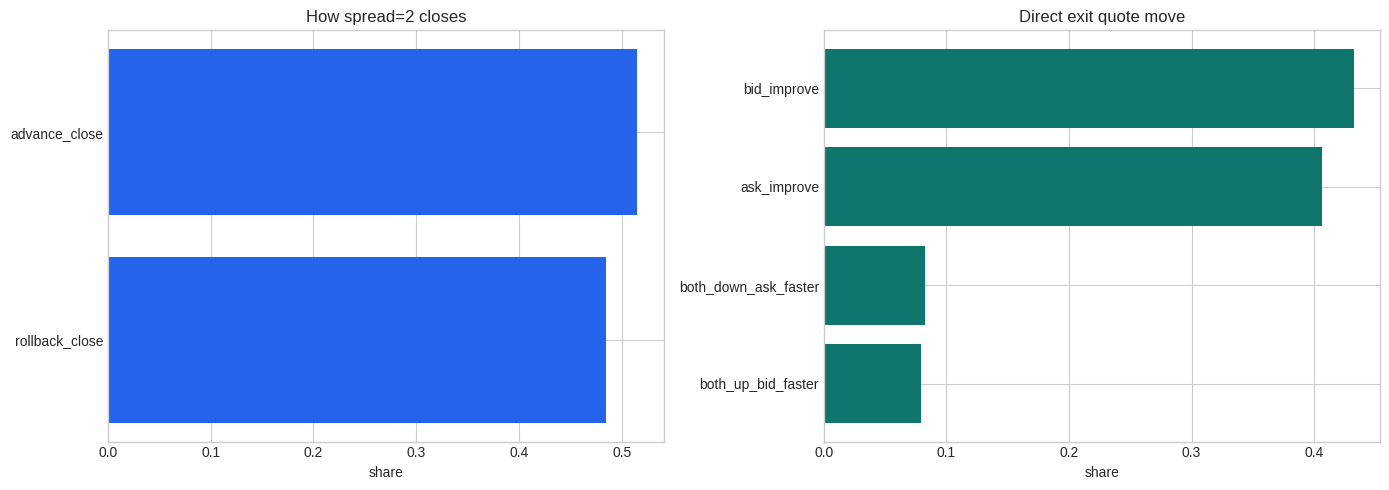

,exit_mechanism,samples,avg_duration_seconds,avg_close_mid_from_pre_entry_tick,avg_signed_close_mid_from_pre_entry_tick,continue_ratio,reverse_ratio,sample_share
0,bid_improve,12764,1.3623,0.5197,0.6769,0.5721,0.0103,0.4322
1,ask_improve,12003,1.3778,-0.5218,0.7024,0.5922,0.0098,0.4065
2,both_down_ask_faster,2428,1.4185,-1.8731,1.0964,0.5478,0.3369,0.0822
3,both_up_bid_faster,2335,1.4218,1.8818,1.0981,0.5362,0.3555,0.0791


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = resolution_summary.sort_values('samples', ascending=True)
axes[0].barh(plot_df['resolution_path'], plot_df['sample_share'], color='#2563eb')
axes[0].set_title('How spread=2 closes')
axes[0].set_xlabel('share')

plot_exit = exit_summary.sort_values('samples', ascending=True)
axes[1].barh(plot_exit['exit_mechanism'], plot_exit['sample_share'], color='#0f766e')
axes[1].set_title('Direct exit quote move')
axes[1].set_xlabel('share')

plt.tight_layout()
plt.show()

display(exit_summary)


### 如何理解

- 如果 `rollback_close + rollback_dominant` 明显更高，说明 `2tick` 回正主要靠原先退开的那边回来，更像回撤式修复。
- 如果 `advance_close + advance_dominant` 更高，说明 `2tick` 回正更多靠另一边跟进，更像价格继续前进后重新压回 `1tick`。
- `exit_mechanism` 是更原始的盘口动作统计；`resolution_path` 则是把这个盘口动作映射成你更关心的“回撤 / 前进”语言。


## 3. 不同 entry 机制下，close path 会不会变


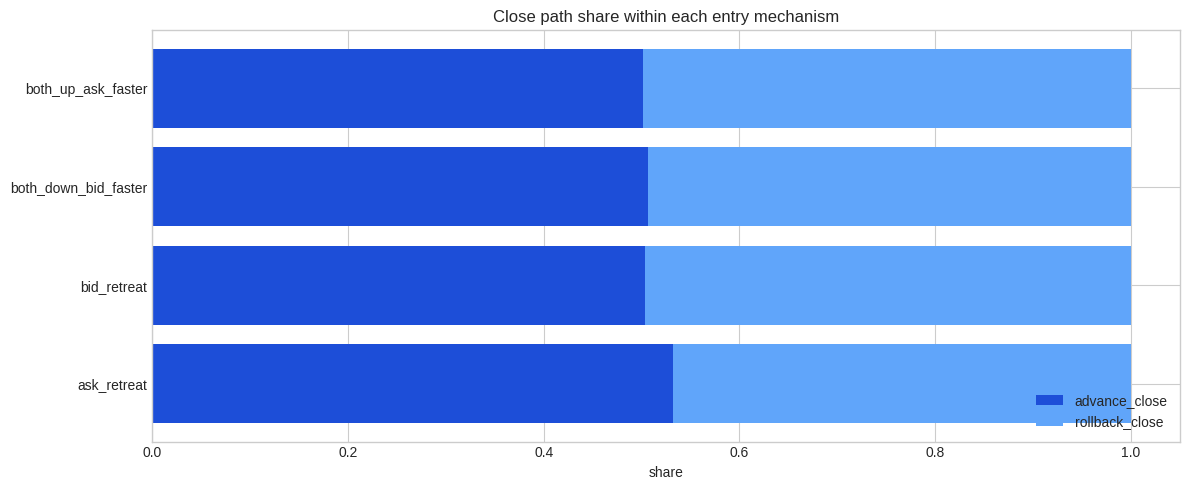

,entry_mechanism,resolution_path,samples,avg_duration_seconds,avg_close_mid_from_pre_entry_tick,avg_signed_close_mid_from_pre_entry_tick,continue_ratio,reverse_ratio,within_entry_share
0,ask_retreat,advance_close,6426,1.3487,1.1455,1.1455,0.9847,0.0034,0.5318
1,ask_retreat,rollback_close,5657,1.3672,-0.1623,-0.1623,0.0228,0.1446,0.4682
2,bid_retreat,advance_close,6263,1.3358,-1.1729,1.1729,0.9866,0.0026,0.5031
3,bid_retreat,rollback_close,6185,1.3347,0.1513,-0.1513,0.0158,0.1361,0.4969
4,both_down_bid_faster,advance_close,1221,1.4611,-2.9533,2.9533,0.9943,0.0033,0.5068
5,both_down_bid_faster,rollback_close,1188,1.5152,-0.8620,0.8620,0.7071,0.0774,0.4932
6,both_up_ask_faster,advance_close,1300,1.5285,2.8885,2.8885,0.9908,0.0038,0.5019
7,both_up_ask_faster,rollback_close,1290,1.6264,0.8209,0.8209,0.7101,0.0760,0.4981


In [4]:
pivot_share = resolution_by_entry.pivot(index='entry_mechanism', columns='resolution_path', values='within_entry_share').fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
left = np.zeros(len(pivot_share))
colors = ['#1d4ed8', '#60a5fa', '#0f766e', '#34d399', '#a3a3a3']
for color, col in zip(colors, pivot_share.columns):
    values = pivot_share[col].values
    ax.barh(pivot_share.index, values, left=left, label=col, color=color)
    left = left + values
ax.set_title('Close path share within each entry mechanism')
ax.set_xlabel('share')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

display(resolution_by_entry.sort_values(['entry_mechanism', 'samples'], ascending=[True, False]))


### 如何理解

- 这里看的是：比如 `ask_retreat` 打开的 `2tick`，最后更多是 `ask` 自己回来，还是 `bid` 追上去。
- 如果不同 `entry_mechanism` 的 close path 差异很大，说明“怎么打开”和“怎么回正”是绑定的，后续建模不应该把所有 `2tick` 放在一个桶里。


## 4. 回正后价格究竟是延续还是回吐

`price_path_label` 的口径：

- `continue`: 从扩价前一秒到回正后一秒，`mid` 仍沿着扩价方向
- `reverse`: 回正后 `mid` 相对扩价前出现反向回吐
- `flat`: 最终又回到了扩价前的中间价附近


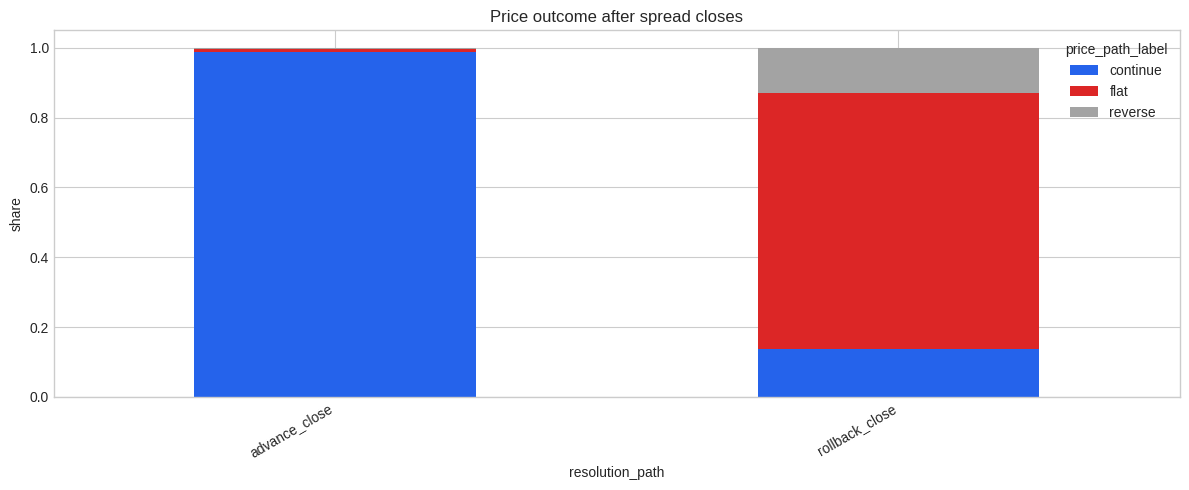

,resolution_path,price_path_label,samples,share
0,advance_close,continue,15009,0.9868
1,advance_close,flat,154,0.0101
2,advance_close,reverse,47,0.0031
4,rollback_close,flat,10487,0.7323
3,rollback_close,continue,1983,0.1385
5,rollback_close,reverse,1850,0.1292


signed_close_mid_from_pre_entry_tick         close_mid_from_pre_entry_tick        close_mid_from_entry_tick       
                                                mean  median                          mean median                      mean median
resolution_path                                                                                                                   
advance_close                                 1.4509  1.0000                        0.0108 1.0000                   -0.0036 0.5000
rollback_close                                0.0160 -0.0000                        0.0037 0.0000                    0.0110 0.5000

In [5]:
price_view = (
    episode_samples.groupby(['resolution_path', 'price_path_label'], observed=False)
    .size()
    .rename('samples')
    .reset_index()
)
price_view['share'] = price_view['samples'] / price_view.groupby('resolution_path')['samples'].transform('sum')

pivot_price = price_view.pivot(index='resolution_path', columns='price_path_label', values='share').fillna(0)
pivot_price.plot(kind='bar', stacked=True, figsize=(12, 5), color=['#2563eb', '#dc2626', '#a3a3a3'])
plt.title('Price outcome after spread closes')
plt.ylabel('share')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

display(price_view.sort_values(['resolution_path', 'samples'], ascending=[True, False]))
display(
    episode_samples.groupby('resolution_path', observed=False)[['signed_close_mid_from_pre_entry_tick', 'close_mid_from_pre_entry_tick', 'close_mid_from_entry_tick']]
    .agg(['mean', 'median'])
)


### 如何理解

- 这一节直接回答“回正是回撤还是前进”。
- 即使盘口层面属于 `advance_close`，价格层面也不一定强延续；反过来，即使是 `rollback_close`，也不代表最后一定完全回吐。
- `signed_close_mid_from_pre_entry_tick` 已经把上下方向做了同向化：正数表示更偏“继续前进”，负数表示更偏“回吐”。
- 所以最稳的读法是把 `resolution_path`、`price_path_label` 和这个 signed 指标结合看，而不是只看其中一张表。


## 5. close 附近的 event study


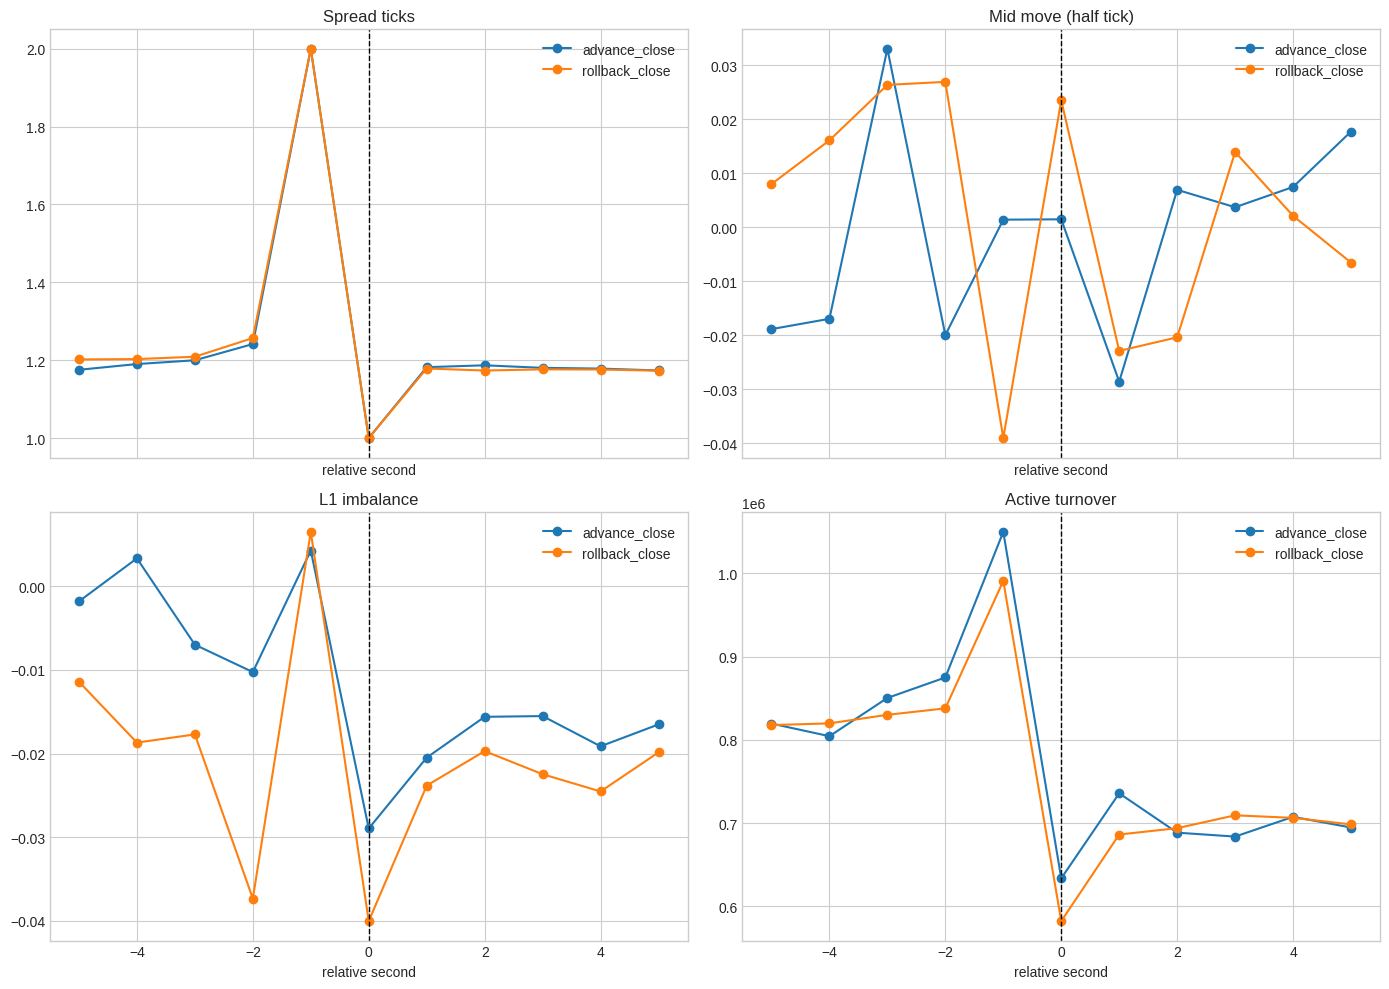

,resolution_path,relative_second,samples,spread_ticks_mean,mid_move_half_tick_mean,l1_imbalance_mean,l1_depth_mean,active_turnover_mean
0,advance_close,-5,15205,1.1753,-0.0189,-0.0018,"279,014.3189","819,535.8324"
1,advance_close,-4,15207,1.1901,-0.0170,0.0033,"278,213.9933","804,363.7231"
2,advance_close,-3,15210,1.1998,0.0330,-0.0070,"275,517.5669","850,300.3780"
3,advance_close,-2,15210,1.2415,-0.0200,-0.0103,"281,644.1388","874,908.4698"
4,advance_close,-1,15210,2.0000,0.0014,0.0043,"402,700.7321","1,049,869.3816"
5,advance_close,0,15210,1.0000,0.0014,-0.0290,"231,048.0256","633,600.7198"
6,advance_close,1,15208,1.1821,-0.0286,-0.0205,"256,521.2824","735,752.5602"
7,advance_close,2,15206,1.1869,0.0069,-0.0156,"263,638.3964","688,439.1584"
8,advance_close,3,15206,1.1803,0.0037,-0.0155,"262,443.0595","683,741.3652"
9,advance_close,4,15205,1.1784,0.0074,-0.0191,"265,558.9883","707,468.3946"


In [6]:
top_paths = resolution_summary.head(3)['resolution_path'].tolist()
plot_event = close_event_study[close_event_study['resolution_path'].isin(top_paths)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
metric_map = {
    'spread_ticks_mean': 'Spread ticks',
    'mid_move_half_tick_mean': 'Mid move (half tick)',
    'l1_imbalance_mean': 'L1 imbalance',
    'active_turnover_mean': 'Active turnover',
}

for ax, (metric, title) in zip(axes.ravel(), metric_map.items()):
    for path in top_paths:
        temp = plot_event[plot_event['resolution_path'] == path]
        ax.plot(temp['relative_second'], temp[metric], marker='o', label=path)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('relative second')
    ax.legend()

plt.tight_layout()
plt.show()

display(plot_event.head(30))


## 6. 样本抽查


In [7]:
display(
    episode_samples.sort_values(['duration_seconds', 'entry_active_turnover'], ascending=[False, False]).head(30)
)


,trade_ymd,entry_time,close_time,entry_time_bucket,duration_seconds,entry_mechanism,entry_direction,entry_mid_move_half_tick,entry_mid_from_pre_entry_tick,entry_l1_imbalance,entry_l3_imbalance,entry_l5_imbalance,entry_l1_depth,entry_l5_depth,entry_active_turnover,episode_active_turnover,episode_net_active_vol,episode_trade_count_delta,episode_mid_from_pre_entry_tick,signed_episode_mid_from_pre_entry_tick,close_mid_from_pre_entry_tick,signed_close_mid_from_pre_entry_tick,close_mid_from_entry_tick,exit_mechanism,exit_bid_move_ticks,exit_ask_move_ticks,exit_mid_move_half_tick,resolution_path,price_path_label
28448,20260417,13:32:40,13:32:59,13:30-14:00,19,ask_retreat,1,1.0000,0.5000,-0.2858,-0.1923,-0.0617,"222,900.0000","3,478,900.0000","53,291.4000","3,046,495.9000","132,000.0000",80.0000,0.5000,0.5000,0.0000,0.0000,-0.5000,ask_improve,0,-1,-1.0000,rollback_close,flat
25392,20260403,13:00:41,13:00:54,13:00-13:30,13,bid_retreat,-1,-1.0000,-0.5000,-0.0765,0.3130,0.2520,"164,600.0000","1,709,300.0000","74,754.6000","487,905.7000","-9,600.0000",27.0000,-0.5000,0.5000,-1.0000,1.0000,-0.5000,ask_improve,0,-1,-1.0000,advance_close,continue
29384,20260423,13:46:24,13:46:35,13:30-14:00,11,bid_retreat,-1,-1.0000,-0.5000,0.0901,-0.0996,-0.0598,"475,900.0000","3,153,400.0000","90,009.1000","662,715.9000","-48,400.0000",35.0000,-0.5000,0.5000,-1.0000,1.0000,-0.5000,ask_improve,0,-1,-1.0000,advance_close,continue
5800,20260119,10:29:21,10:29:32,10:00-10:30,11,ask_retreat,1,1.0000,0.5000,-0.6686,-0.2180,0.2214,"429,700.0000","2,750,200.0000","89,762.4000","2,743,603.5000","-236,500.0000",47.0000,-0.5000,-0.5000,0.0000,0.0000,-0.5000,bid_improve,1,0,1.0000,advance_close,flat
21033,20260323,13:47:34,13:47:44,13:30-14:00,10,both_up_ask_faster,1,7.0000,3.5000,-0.1088,0.3595,0.4120,"125,000.0000","2,064,400.0000","5,858,536.3000","9,139,837.6000","398,600.0000",164.0000,-0.5000,-0.5000,-1.0000,-1.0000,-4.5000,ask_improve,0,-1,-1.0000,rollback_close,reverse
23695,20260331,10:32:27,10:32:37,10:30-11:00,10,both_down_bid_faster,-1,-3.0000,-1.5000,0.8951,0.6204,0.4781,"55,300.0000","1,706,300.0000","722,772.4000","3,716,655.0000","126,000.0000",80.0000,0.5000,-0.5000,2.0000,-2.0000,3.5000,both_up_bid_faster,2,1,3.0000,rollback_close,reverse
24057,20260331,13:28:20,13:28:30,13:00-13:30,10,ask_retreat,1,1.0000,0.5000,0.0992,0.3907,0.1642,"102,800.0000","990,900.0000","719,495.0000","2,963,591.4000","-3,800.0000",54.0000,1.5000,1.5000,2.0000,2.0000,1.5000,bid_improve,1,0,1.0000,advance_close,continue
22770,20260327,11:12:00,11:12:10,11:00-11:30,10,ask_retreat,1,1.0000,0.5000,-0.6882,-0.0483,-0.2846,"188,600.0000","2,213,100.0000","116,795.2000","1,952,250.1000","33,100.0000",37.0000,-1.5000,-1.5000,-1.0000,-1.0000,-1.5000,bid_improve,1,0,1.0000,advance_close,reverse
26712,20260409,10:53:47,10:53:56,10:30-11:00,9,both_down_bid_faster,-1,-3.0000,-1.5000,-0.0677,-0.1450,-0.0329,"927,400.0000","4,786,700.0000","2,809,972.5000","4,502,993.2000","-346,200.0000",135.0000,-1.5000,1.5000,-2.0000,2.0000,-0.5000,ask_improve,0,-1,-1.0000,advance_close,continue
8250,20260129,11:26:01,11:26:10,11:00-11:30,9,both_up_ask_faster,1,3.0000,1.5000,-0.6213,0.2701,0.3376,"184,300.0000","1,339,600.0000","2,153,672.8000","3,984,594.4000","86,800.0000",75.0000,1.5000,1.5000,3.0000,3.0000,1.5000,both_up_bid_faster,2,1,3.0000,advance_close,continue
